<h2 style="color:#4CAF50;"> Importing Libraries</h2>

In [1]:
import sys
sys.path.insert(0, r"C:\Users\manpu\Downloads\Ambulence_call_volume_Shylender_Rao_Dissertation_final\Toshylandhar\Shylendar_Ambulence_Call_Volume_FE")

from lib_file import lib_path
print(lib_path)

C:\Users\manpu\Downloads\Ambulence_call_volume_Shylender_Rao_Dissertation_final\Toshylandhar\Shylendar_Ambulence_Call_Volume_FE


In [2]:
!pip install holidays

In [3]:
import joblib
import pandas as pd
import numpy as np
import holidays
from sklearn.base import BaseEstimator, TransformerMixin
from lib_file import lib_path

 <h2 style="color:#4CAF50;"> FeatureEngineer</h2>

In [4]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ie_holidays = holidays.Ireland()
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X, y=None):
        X = X.copy()
        
        # Create datetime column
        X['datetime'] = pd.to_datetime(X[['year', 'month', 'day', 'hour']])
        
        # Basic temporal features
        X['day_of_week'] = X['datetime'].dt.dayofweek
        X['is_weekend'] = (X['day_of_week'] >= 5).astype(int)
        X['is_holiday'] = X['datetime'].apply(lambda x: x in self.ie_holidays).astype(int)
        
        # Time of day features
        X['is_night'] = ((X['hour'] >= 0) & (X['hour'] <= 6)).astype(int)
        X['is_morning'] = ((X['hour'] >= 7) & (X['hour'] <= 11)).astype(int)
        X['is_afternoon'] = ((X['hour'] >= 12) & (X['hour'] <= 17)).astype(int)
        X['is_evening'] = ((X['hour'] >= 18) & (X['hour'] <= 23)).astype(int)
        
        # Cyclical encoding
        X['hour_sin'] = np.sin(2 * np.pi * X['hour']/24)
        X['hour_cos'] = np.cos(2 * np.pi * X['hour']/24)
        X['month_sin'] = np.sin(2 * np.pi * X['month']/12)
        X['month_cos'] = np.cos(2 * np.pi * X['month']/12)
        
        # Seasonality
        X['season'] = X['month'] % 12 // 3 + 1
        
        # Drop datetime & day_of_week
        X = X.drop(columns=['datetime', 'day_of_week'])
        
        return X

***Load Models***

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
# ====== Load Gradient Boosting Model & Label Encoder ======
model_path = "models/xgb.pkl"
encoder_path = "models/station_id_label_encoder.pkl"

gbr_model = joblib.load(model_path)
station_id_encoder = joblib.load(encoder_path)

***Input***

In [7]:
def predict_calls(station_id, year, month, day, hour):
    # Prepare input dataframe
    input_df = pd.DataFrame({
        'station_id': [station_id],
        'year': [year],
        'month': [month],
        'day': [day],
        'hour': [hour]
    })
    
    # Apply label encoding to station_id
    input_df['station_id'] = station_id_encoder.transform(input_df['station_id'])
    
    # Apply feature engineering
    fe = FeatureEngineer()
    input_eng = fe.transform(input_df)
    
    # Predict with Gradient Boosting Regressor
    prediction = gbr_model.predict(input_eng)[0]
    
    return int(round(prediction))

***Output***

In [10]:
# Example Usage
if __name__ == "__main__":
    result = predict_calls( "Balbriggan Fire Station", 2020, 12, 1, 3)  #YYYY, MM, DD, HH 
    print(f"Predicted Hourly Calls: {result}")



Predicted Hourly Calls: 3


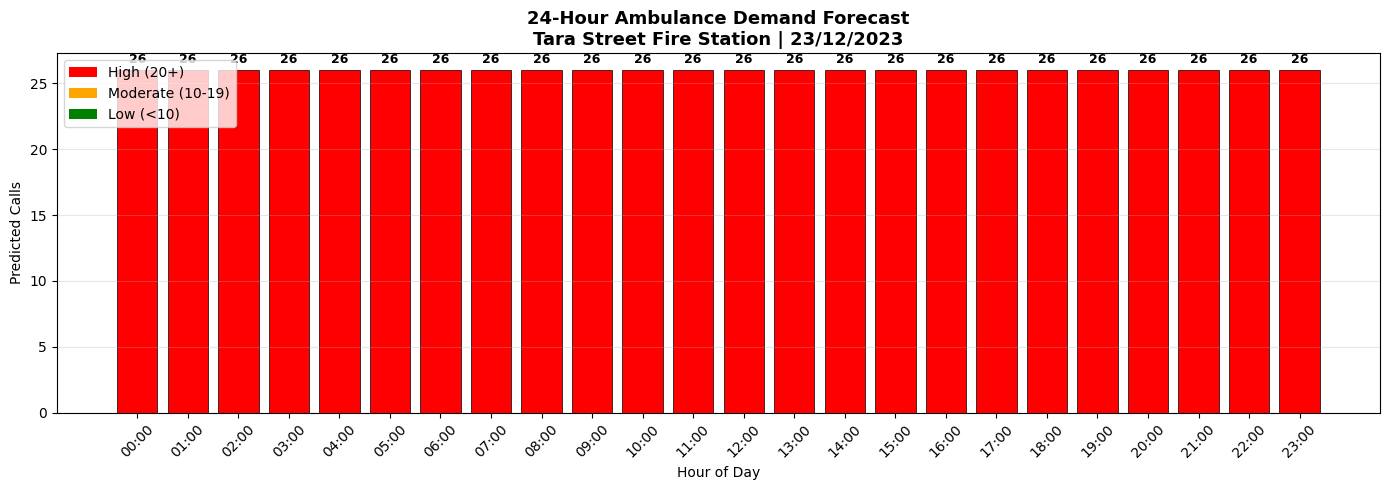

✅ Peak hour: 00:00 with 26 calls
✅ Quietest hour: 00:00 with 26 calls


In [9]:
import matplotlib.pyplot as plt

STATION = "Tara Street Fire Station"
YEAR, MONTH, DAY = 2023, 12, 23

hours = list(range(24))
preds = [predict_calls(STATION, YEAR, MONTH, DAY, h) for h in hours]

colors = ['red' if p>=20 else 'orange' if p>=10 else 'green' for p in preds]

plt.figure(figsize=(14,5))
bars = plt.bar(hours, preds, color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, preds):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title(f'24-Hour Ambulance Demand Forecast\n{STATION} | {DAY:02d}/{MONTH:02d}/{YEAR}',
          fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Predicted Calls')
plt.xticks(hours, [f'{h:02d}:00' for h in hours], rotation=45)
plt.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(facecolor='red',    label='High (20+)'),
    Patch(facecolor='orange', label='Moderate (10-19)'),
    Patch(facecolor='green',  label='Low (<10)')
], loc='upper left')
plt.tight_layout()
plt.show()
print(f"✅ Peak hour: {hours[preds.index(max(preds))]:02d}:00 with {max(preds)} calls")
print(f"✅ Quietest hour: {hours[preds.index(min(preds))]:02d}:00 with {min(preds)} calls")